In [ ]:
!pip install inference-sdk opencv-python numpy --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.5/181.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.2 MB/s eta 0:00:00


In [ ]:
import cv2
import numpy as np
from inference_sdk import InferenceHTTPClient
from google.colab.patches import cv2_imshow
from google.colab import files


In [ ]:
CLIENT = InferenceHTTPClient(
    api_url="https://detect.roboflow.com",
    api_key="D0q6MwUDGlZ293KYKi9a"
)

In [ ]:
FOCAL_LENGTH = 2500  # in pixels
BASELINE = 1        # in meters
PAD = 10  #bounding box padding to improve matching

In [ ]:
def detect_objects(image_path):
    image = cv2.imread(image_path)
    if image is None:
        print(f" Error: Could not read image {image_path}")
        return None, None, None, None

    result = CLIENT.infer(image, model_id="window-and-door-detection/1")

    detected_objects = []
    for pred in result['predictions']:
        if pred['confidence'] < 0.5:
            continue

        # These values come from the prediction returned by the object detection model
        # x and y represent the center of the bounding box (not the top-left corner)
        # width and height specify how big the box is.
        x = int(pred['x'])
        y = int(pred['y'])
        width = int(pred['width'])
        height = int(pred['height'])

        x1 = max(0, x - width // 2 - PAD)
        y1 = max(0, y - height // 2 - PAD)
        x2 = min(image.shape[1], x + width // 2 + PAD)
        y2 = min(image.shape[0], y + height // 2 + PAD)

        label = pred['class']
        confidence = pred['confidence']
        cropped = image[y1:y2, x1:x2]

        detected_objects.append({
            "center_x": x,
            "center_y": y,
            "bbox": (x1, y1, x2, y2),
            "label": label,
            "confidence": confidence,
            "cropped": cropped
        })

    return detected_objects, image, image.shape[1], image_path

In triangulation, the angles from each camera toward the object help form a triangle with the baseline as the base.

In [ ]:
def estimate_distance_from_disparity(x1, x2, img_width, focal_length, baseline):
    cx = img_width / 2
    theta1 = np.arctan((x1 - cx) / focal_length)
    theta2 = np.arctan((x2 - cx) / focal_length)

    if abs(np.tan(theta1) - np.tan(theta2)) < 1e-5:
        print("Angle difference too small for triangulation.")
        return None

    distance = abs(baseline / (np.tan(theta1) - np.tan(theta2)))
    return distance

In [ ]:
def orb_match(img1, img2):
    orb = cv2.ORB_create(nfeatures=1000)
    kp1, des1 = orb.detectAndCompute(cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY), None)
    kp2, des2 = orb.detectAndCompute(cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY), None)

    print(f"ORB keypoints: img1 = {len(kp1) if kp1 else 0}, img2 = {len(kp2) if kp2 else 0}")

    if des1 is None or des2 is None:
        return 0

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    return len(matches)

In [ ]:
print("Upload two images of the same scene (left and right views):")
uploaded = files.upload()
image_paths = list(uploaded.keys())

Upload two images of the same scene (left and right views):


Saving IMG-20250504-WA0151.jpg to IMG-20250504-WA0151.jpg
Saving IMG-20250504-WA0152.jpg to IMG-20250504-WA0152.jpg


ORB keypoints: img1 = 55, img2 = 74
 Label: Windows, Matches: 35
ORB keypoints: img1 = 0, img2 = 0
 Label: Windows, Matches: 0
ORB keypoints: img1 = 0, img2 = 0
 Label: Windows, Matches: 0
ORB keypoints: img1 = 0, img2 = 0
 Label: Windows, Matches: 0
ORB keypoints: img1 = 0, img2 = 0
 Label: Windows, Matches: 0

 Matched object: Windows with 35 ORB matches
 Estimated distance: 10.04 meters

 Matched object in left image:


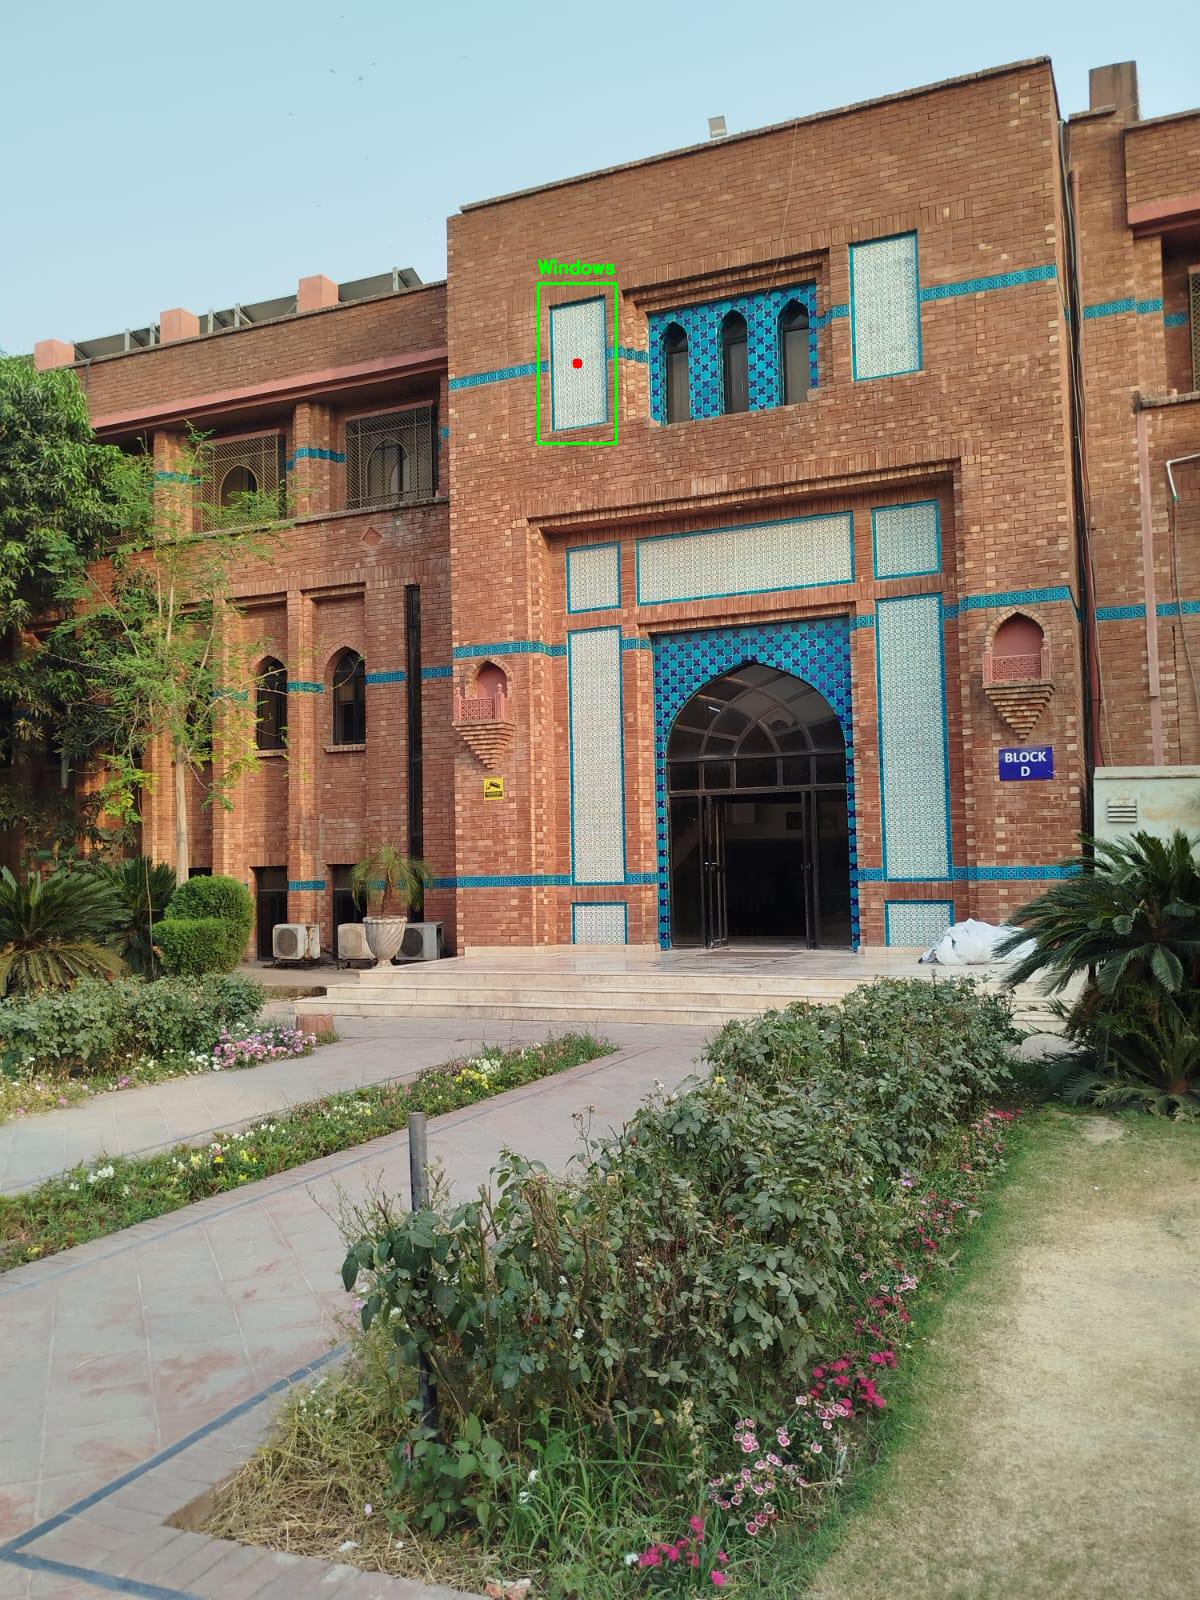


 Matched object in right image:


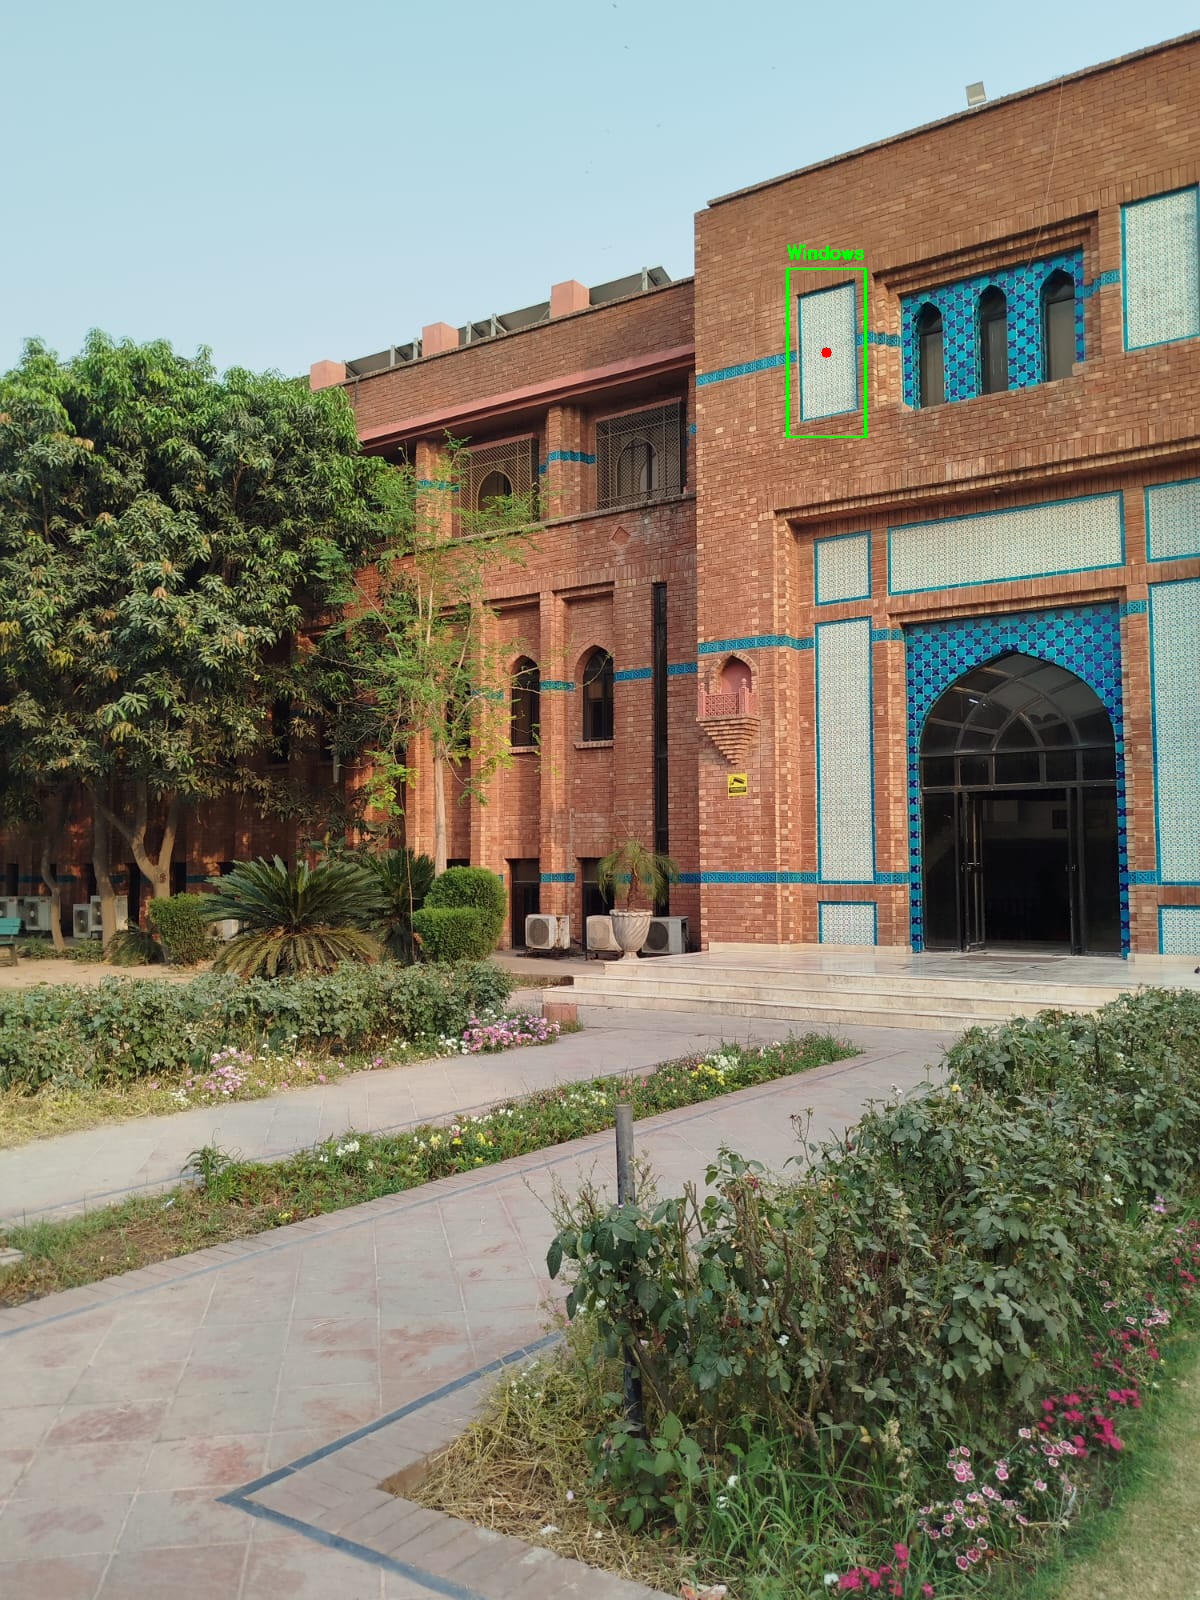

In [ ]:
if len(image_paths) != 2:
    print("Please upload exactly two images.")
else:
    objects1, full_img1, width1, path1 = detect_objects(image_paths[0])
    objects2, full_img2, width2, path2 = detect_objects(image_paths[1])

    if objects1 is None or objects2 is None:
        print("Error processing images.")
    else:
        labels1 = set(obj['label'] for obj in objects1)
        labels2 = set(obj['label'] for obj in objects2)
        common_labels = labels1 & labels2

        best_match = None
        max_matches = 0

        for label in common_labels:
            objs1 = [obj for obj in objects1 if obj['label'] == label]
            objs2 = [obj for obj in objects2 if obj['label'] == label]

            for o1 in objs1:
                for o2 in objs2:
                    #Pre-filtering using y-coordinate and reasonable x-disparity
                    if abs(o1['center_y'] - o2['center_y']) > 30:
                        continue  # Skip if vertical alignment is too different
                    if abs(o1['center_x'] - o2['center_x']) > width1:
                        continue  # Skip if horizontal shift is too large

                    matches = orb_match(o1['cropped'], o2['cropped'])
                    print(f" Label: {label}, Matches: {matches}")
                    if matches > max_matches:
                        max_matches = matches
                        best_match = (o1, o2)

        if best_match:
            o1, o2 = best_match
            distance = estimate_distance_from_disparity(
                o1['center_x'], o2['center_x'], width1, FOCAL_LENGTH, BASELINE
            )

            for img, obj in [(full_img1, o1), (full_img2, o2)]:
                x1, y1, x2, y2 = obj['bbox']
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(img, obj['label'], (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
                cv2.circle(img, (int(obj['center_x']), int(obj['center_y'])),
                           5, (0, 0, 255), -1)

            print(f"\n Matched object: {o1['label']} with {max_matches} ORB matches")
            if distance:
                print(f" Estimated distance: {distance:.2f} meters")

            print("\n Matched object in left image:")
            cv2_imshow(full_img1)
            print("\n Matched object in right image:")
            cv2_imshow(full_img2)
        else:
            print(" No good object match found using ORB and coordinates.")